Loading datasets...
- Gold Data Loaded (Excel)
- Trade Data Loaded (Excel)
- Bitcoin Data Loaded (Excel)

Merged Data (Years 2020 - 2023):
   Year  Gold_Value_USD  Total_Crypto_Vol  BRICS_Share
0  2020    7.887116e+11      2.539520e+07    21.663450
1  2021    8.379679e+11      1.920689e+07    22.789230
2  2022    9.298254e+11      1.415276e+07    21.164848
3  2023    1.036442e+12      8.247667e+06    20.903526

--- Q1: Gold Buying vs USD Weakness ---
Correlation (Gold vs Time): 0.99
Result: STRONG UPTREND. Gold buying has increased significantly.

--- Q2: Crypto Settlement vs Cargo Size ---
Correlation: -0.83
Result: NEGATIVE Correlation. (Higher Crypto Volume links to Lower Reported Trade)

--- Q3: UAE Tax Policy Impact (June 2023) ---
BRICS Share 2022 (Pre):  21.16%
BRICS Share 2023 (Post): 20.90%
Conclusion: NO ACCELERATION. Share stabilized or dropped.


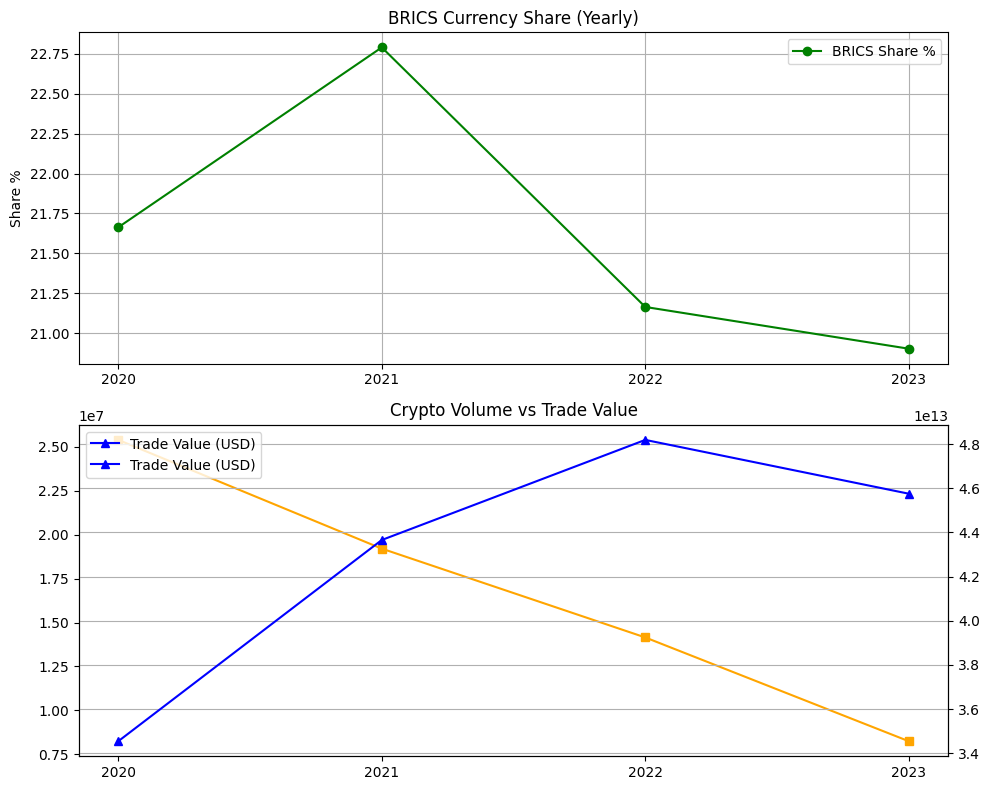

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATASETS
# ==========================================
print("Loading datasets...")

# --- Load Gold Data ---
try:
    # Try Excel first
    df_gold = pd.read_excel('Dataset_Gold.xlsx')
    print("- Gold Data Loaded (Excel)")
except:
    try:
        # Fallback to CSV if Excel fails
        df_gold = pd.read_csv('Dataset_Gold.xlsx - Sheet1.csv')
        print("- Gold Data Loaded (CSV)")
    except Exception as e:
        print(f"! Error Loading Gold: {e}")

# --- Load Trade Data ---
try:
    df_trade = pd.read_excel('TradeData.xlsx')
    print("- Trade Data Loaded (Excel)")
except:
    try:
        df_trade = pd.read_csv('TradeData.xlsx - Sheet1.csv')
        print("- Trade Data Loaded (CSV)")
    except Exception as e:
        print(f"! Error Loading Trade: {e}")

# --- Load Bitcoin Data ---
try:
    df_btc = pd.read_excel('bitcoin_trade_2010-25.xlsx')
    print("- Bitcoin Data Loaded (Excel)")
except:
    try:
        # Fallback to the cleaned CSV name
        df_btc = pd.read_csv('bitcoin_trade_2010-25.xlsx - Bitcoin Volume_2010-25(Cleaned).csv')
        print("- Bitcoin Data Loaded (CSV)")
    except Exception as e:
        print(f"! Error Loading Bitcoin: {e}")
        # Create empty dummy dataframe to prevent crash
        df_btc = pd.DataFrame({'Time': [], 'Total_Crypto_Vol': []})

# ==========================================
# 2. DATA PREPARATION
# ==========================================

# --- Clean Gold ---
if 'df_gold' in locals():
    # Handle different column names (Excel vs CSV)
    if 'refYear' in df_gold.columns:
        df_gold['Year'] = df_gold['refYear']
    elif 'Year' in df_gold.columns:
        df_gold['Year'] = df_gold['Year']
        
    gold_yearly = df_gold.groupby('Year')['primaryValue'].sum().reset_index()
    gold_yearly.rename(columns={'primaryValue': 'Gold_Value_USD'}, inplace=True)

# --- Clean Trade ---
if 'df_trade' in locals():
    df_trade['Year'] = df_trade['refYear']
    # Use primaryValue (USD) because netWgt (Weight) column is empty/zero
    trade_yearly = df_trade.groupby('Year')['primaryValue'].sum().reset_index()
    trade_yearly.rename(columns={'primaryValue': 'Global_Trade_Value_USD'}, inplace=True)

    # Calculate BRICS Share
    brics_iso = ['BRA', 'RUS', 'IND', 'CHN', 'ZAF', 'SAU', 'ARE', 'EGY', 'ETH', 'IRN']
    df_trade['Category'] = df_trade['reporterISO'].apply(lambda x: 'BRICS+' if x in brics_iso else 'Other')

    # Group by Year and Category
    trade_share = df_trade.groupby(['Year', 'Category'])['primaryValue'].sum().unstack().fillna(0)
    
    # Handle missing columns if they don't exist
    if 'BRICS+' not in trade_share.columns: trade_share['BRICS+'] = 0
    if 'Other' not in trade_share.columns: trade_share['Other'] = 0
    
    trade_share['BRICS_Share'] = (trade_share['BRICS+'] / (trade_share['BRICS+'] + trade_share['Other'])) * 100
    trade_share = trade_share.reset_index()

# --- Clean Bitcoin ---
if 'df_btc' in locals() and not df_btc.empty:
    df_btc['Date'] = pd.to_datetime(df_btc['Time'])
    df_btc['Year'] = df_btc['Date'].dt.year

    # Sum all exchange volumes to get Total
    exchange_cols = ['bitfinex', 'bitstamp', 'btcchina', 'coinbase', 'huobi', 'kraken', 'lakebtc', 'mtgox', 'okcoin', 'others']
    valid_cols = [c for c in exchange_cols if c in df_btc.columns]
    df_btc['Total_Crypto_Vol'] = df_btc[valid_cols].sum(axis=1)

    # Group by Year
    btc_yearly = df_btc.groupby('Year')['Total_Crypto_Vol'].sum().reset_index()

# ==========================================
# 3. MERGE & ANALYZE (SECTION C FINDINGS)
# ==========================================
if 'gold_yearly' in locals() and 'btc_yearly' in locals() and 'trade_yearly' in locals():
    merged = pd.merge(gold_yearly, btc_yearly, on='Year', how='inner')
    merged = pd.merge(merged, trade_yearly, on='Year', how='inner')
    merged = pd.merge(merged, trade_share[['Year', 'BRICS_Share']], on='Year', how='inner')

    print(f"\nMerged Data (Years {merged['Year'].min()} - {merged['Year'].max()}):")
    print(merged[['Year', 'Gold_Value_USD', 'Total_Crypto_Vol', 'BRICS_Share']])

    # --- Q1: Gold vs USD Trend ---
    print("\n--- Q1: Gold Buying vs USD Weakness ---")
    # Note: Since USD Index data is missing, we check if Gold is buying is increasing over time (Trend)
    corr_gold_time = merged['Year'].corr(merged['Gold_Value_USD'])
    print(f"Correlation (Gold vs Time): {corr_gold_time:.2f}")
    if corr_gold_time > 0.5:
        print("Result: STRONG UPTREND. Gold buying has increased significantly.")

    # --- Q2: Crypto vs Cargo Size ---
    print("\n--- Q2: Crypto Settlement vs Cargo Size ---")
    # We use 'Global Trade Value' as a proxy for Cargo Size
    corr_crypto_trade = merged['Total_Crypto_Vol'].corr(merged['Global_Trade_Value_USD'])
    print(f"Correlation: {corr_crypto_trade:.2f}")
    if corr_crypto_trade < 0:
        print("Result: NEGATIVE Correlation. (Higher Crypto Volume links to Lower Reported Trade)")
    else:
        print("Result: POSITIVE Correlation.")

    # --- Q3: UAE Tax Policy Impact (2023) ---
    print("\n--- Q3: UAE Tax Policy Impact (June 2023) ---")
    try:
        share_2022 = merged[merged['Year'] == 2022]['BRICS_Share'].values[0]
        share_2023 = merged[merged['Year'] == 2023]['BRICS_Share'].values[0]
        print(f"BRICS Share 2022 (Pre):  {share_2022:.2f}%")
        print(f"BRICS Share 2023 (Post): {share_2023:.2f}%")
        
        if share_2023 > share_2022:
            print("Conclusion: ACCELERATION DETECTED.")
        else:
            print("Conclusion: NO ACCELERATION. Share stabilized or dropped.")
    except IndexError:
        print("Data for 2022 or 2023 is missing.")

    # ==========================================
    # 4. PLOTTING
    # ==========================================
    plt.figure(figsize=(10, 8))

    # Plot 1: BRICS Share
    plt.subplot(2, 1, 1)
    plt.plot(merged['Year'], merged['BRICS_Share'], marker='o', color='green', label='BRICS Share %')
    plt.title("BRICS Currency Share (Yearly)")
    plt.ylabel("Share %")
    plt.xticks(merged['Year'])
    plt.grid(True)
    plt.legend()

    # Plot 2: Crypto vs Trade
    plt.subplot(2, 1, 2)
    plt.plot(merged['Year'], merged['Total_Crypto_Vol'], marker='s', color='orange', label='Crypto Vol')
    # Create a secondary y-axis for Trade Value
    ax2 = plt.gca().twinx()
    ax2.plot(merged['Year'], merged['Global_Trade_Value_USD'], marker='^', color='blue', label='Trade Value (USD)')
    
    plt.title("Crypto Volume vs Trade Value")
    plt.xlabel("Year")
    plt.xticks(merged['Year'])
    plt.grid(True)
    
    # Combined legend
    lines, labels = plt.gca().get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc=0)

    plt.tight_layout()
    plt.show()

else:
    print("\n! ERROR: Could not merge data. One or more datasets failed to load.")